# 02h - Demo Mexico aguacate/guayaba (zero-shot CUALITATIVO, US-077)

Aplicamos el **mismo pipeline** del baseline europeo (embedding AlphaEarth zonal + curva NDVI fenologica de Sentinel-2 + descripcion-texto con Gemini) a dos zonas productoras reales de Mexico, usando AlphaEarth `V1/ANNUAL`, que es **global e incluye Mexico** (CC-BY-4.0).

> **METODOLOGIA ZERO-SHOT CUALITATIVA -- SIN CLAIM DE EXACTITUD.** El objetivo es mostrar que la **metodologia es replicable** a otras zonas, no medir su exactitud. **NO reportamos F1 ni accuracy para Mexico**: no existe un conjunto de ground-truth curado de aguacate/guayaba que permita validarlo. Lo que mostramos es REAL (la curva NDVI de la parcela, su embedding AlphaEarth y la descripcion fenologica generada); lo que dejamos como **trabajo futuro** es la validacion metrica (un F1>=0.80 mexicano requiere muestras etiquetadas curadas, fuera de alcance de esta presentacion).

**Lo que SI mostramos** (todo REAL, de GEE):
- El embedding AlphaEarth 64-dim zonal de cada AOI (la firma satelital).
- La curva NDVI temporal 2023 de Sentinel-2 (la fenologia observada).
- La descripcion fenologica generada por Gemini (la alineacion fenologia-texto).

**Lo que NO mostramos** (y por que):
- Ningun F1/accuracy/clasificador sobre Mexico: no hay ground-truth curado de aguacate/guayaba. Cualquier numero de clasificacion seria una sobre-afirmacion. El encuadre HCAT (orchard) es **analogia cualitativa**, NO una prediccion.

Aguacate y guayaba son cultivos **perennes arboreos** (no estacionales): su firma NDVI esperada es alta y relativamente **estable todo el anio** (sin el ciclo siembra-cosecha de un cereal anual). Eso es justo lo que la curva REAL debe revelar.

In [1]:
# Parametros papermill (defaults para entregable; degraded para el smoke de CI).
year = 2023
cloud_pct_max = 40       # mas permisivo que el 30 europeo (nubosidad tropical)
buffer_m = 1500          # ~7 km2 por AOI (promedia la huerta)
gemini_model = 'gemini-3.5-flash'
degraded = False         # True = sin GEE; muestra el pipeline + placeholder


In [2]:
from __future__ import annotations

from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

from ml.utils.notebook_setup import find_repo_root, configure_ee_from_env
from ml.ingest.gee_sampler import init_ee
from ml.transfer import mexico_demo as mx

repo_root = find_repo_root()
# AOIs reales (coords EPSG:4326 verificadas en GEE); aplicamos el buffer del parametro.
aois = tuple(replace(a, buffer_m=buffer_m) for a in mx.DEFAULT_AOIS)

# Bootstrap GEE: service account .env/gee-service-account.json (agrosat-copilot).
if not degraded:
    try:
        proj, sa = configure_ee_from_env(repo_root)
        default_sa = repo_root / '.env' / 'gee-service-account.json'
        sa_path = sa if sa is not None else default_sa
        sa_path = sa_path if sa_path.is_file() else None
        init_ee(service_account_json=sa_path, project=proj)
        auth_msg = (
            f'Earth Engine inicializado (project=`{proj}`, '
            f'service_account={"si" if sa_path else "ADC"}).'
        )
    except Exception as exc:  # noqa: BLE001 -- degradar sin romper el notebook
        degraded = True
        auth_msg = (
            f'GEE no disponible ({exc}); modo `degraded` -> '
            'placeholder, sin curva inventada.'
        )
else:
    auth_msg = (
        'Modo `degraded` forzado por parametro: pipeline mostrado, '
        'sin llamadas GEE.'
    )
display(Markdown(f'**Auth GEE**: {auth_msg}'))


**Auth GEE**: Earth Engine inicializado (project=`agrosat-copilot`, service_account=si).

## 1. Las AOIs mexicanas (coordenadas REALES)

Dos zonas productoras reales y documentadas. Geometria = `ee.Geometry.Point(lon,lat).buffer(buffer_m)`. Centroides elegidos sobre vegetacion arborea conocida, lejos de mancha urbana.

In [3]:
aoi_table = pl.DataFrame(
    {
        'aoi': [a.name for a in aois],
        'cultivo': [a.crop for a in aois],
        'lon': [a.lon for a in aois],
        'lat': [a.lat for a in aois],
        'buffer_m': [a.buffer_m for a in aois],
        'fenologia_esperada': [a.expected_phenology for a in aois],
    }
)
display(aoi_table)
display(Markdown(
    '- **AOI-1 aguacate**: Uruapan / faldas del Tancitaro, Michoacan '
    '(cinturon aguacatero).\n'
    '- **AOI-2 guayaba**: Calvillo, Aguascalientes (capital nacional de la guayaba).'
))


aoi,cultivo,lon,lat,buffer_m,fenologia_esperada
str,str,f64,f64,i64,str
"""aguacate_uruapan""","""aguacate""",-102.05,19.41,1500,"""Perenne arboreo: NDVI alto y e…"
"""guayaba_calvillo""","""guayaba""",-102.72,21.85,1500,"""Perenne arboreo subtropical: N…"


- **AOI-1 aguacate**: Uruapan / faldas del Tancitaro, Michoacan (cinturon aguacatero).
- **AOI-2 guayaba**: Calvillo, Aguascalientes (capital nacional de la guayaba).

## 2. Embedding AlphaEarth 64-dim zonal REAL (la firma satelital)

`reduceRegion(mean)` del mosaico AlphaEarth del anio sobre el buffer de cada AOI -> un vector de 64 dimensiones REAL por cultivo. Es la representacion aprendida del foundation model EO, exactamente la misma feature que alimenta el baseline europeo.

In [4]:
alphaearth_rows = []
embeddings = {}
if not degraded:
    for a in aois:
        vec = mx.extract_alphaearth_zonal(a, year)
        embeddings[a.name] = vec
        if vec.size == mx.ALPHAEARTH_N_DIMS:
            alphaearth_rows.append(
                {
                    'aoi': a.name,
                    'cultivo': a.crop,
                    'n_dims': int(vec.size),
                    'norm': float(np.linalg.norm(vec)),
                    'A00': float(vec[0]),
                    'A01': float(vec[1]),
                    'A02': float(vec[2]),
                }
            )
        else:
            display(Markdown(
                f'> **AOI `{a.name}`**: AlphaEarth vacio (GEE no devolvio datos). '
                'Sin vector inventado.'
            ))
    if alphaearth_rows:
        display(pl.DataFrame(alphaearth_rows))
else:
    display(Markdown('> **Modo degradado**: no se consulta AlphaEarth (sin GEE).'))


aoi,cultivo,n_dims,norm,A00,A01,A02
str,str,i64,f64,f64,f64,f64
"""aguacate_uruapan""","""aguacate""",64,0.907816,0.155285,-0.232075,0.025338
"""guayaba_calvillo""","""guayaba""",64,0.854169,0.070011,-0.120513,0.119958


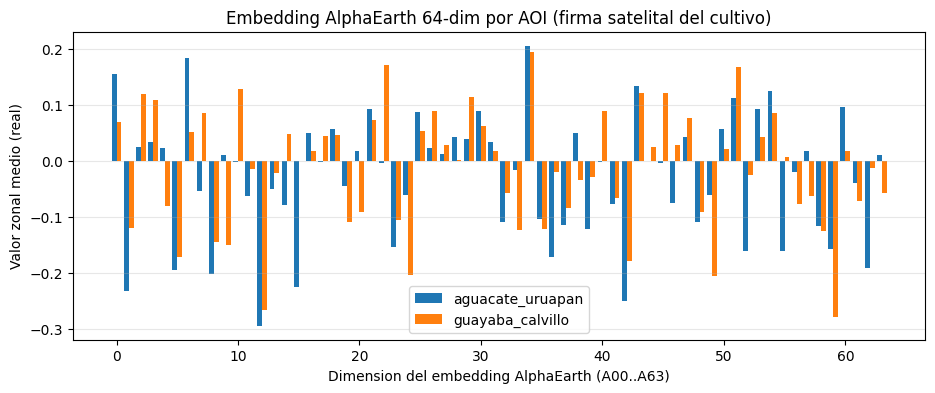

In [5]:
# Figura 1: barra del embedding 64-dim por AOI (la firma satelital real).
valid_emb = {k: v for k, v in embeddings.items() if v.size == mx.ALPHAEARTH_N_DIMS}
if not degraded and valid_emb:
    fig, ax = plt.subplots(figsize=(11, 4))
    dims = np.arange(mx.ALPHAEARTH_N_DIMS)
    width = 0.4
    for i, (name, vec) in enumerate(valid_emb.items()):
        ax.bar(dims + (i - 0.5) * width, vec, width=width, label=name)
    ax.set_xlabel('Dimension del embedding AlphaEarth (A00..A63)')
    ax.set_ylabel('Valor zonal medio (real)')
    ax.set_title('Embedding AlphaEarth 64-dim por AOI (firma satelital del cultivo)')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    display(fig)
    plt.close(fig)
else:
    display(Markdown('> **Modo degradado / sin datos**: figura del embedding omitida.'))


## 3. Curva NDVI temporal REAL 2023 (la fenologia observada)

Coleccion Sentinel-2 `S2_SR_HARMONIZED` con mascara de nubes QA60, NDVI `normalizedDifference(['B8','B4'])` y `reduceRegion(mean)` por imagen. Se reporta el numero de imagenes usadas (auditable). La firma esperada del perenne arboreo es una curva **alta y estable**, sin el pico unico estacional de un cultivo anual.

In [6]:
ndvi_series = {}
if not degraded:
    for a in aois:
        ser = mx.extract_s2_ndvi_series(a, year, cloud_pct_max=cloud_pct_max)
        ndvi_series[a.name] = ser
        if ser.is_empty():
            display(Markdown(
                f'> **AOI `{a.name}`**: serie NDVI vacia (GEE no devolvio imagenes). '
                'Sin curva inventada.'
            ))
        else:
            display(Markdown(
                f'- **{a.name}** ({a.crop}): {ser.height} imagenes S2 usadas, '
                f'NDVI medio {ser["ndvi"].mean():.3f}, '
                f'rango [{ser["ndvi"].min():.3f}, {ser["ndvi"].max():.3f}].'
            ))
else:
    display(Markdown('> **Modo degradado**: no se consulta Sentinel-2 (sin GEE).'))


- **aguacate_uruapan** (aguacate): 104 imagenes S2 usadas, NDVI medio 0.188, rango [-0.016, 0.251].

- **guayaba_calvillo** (guayaba): 60 imagenes S2 usadas, NDVI medio 0.213, rango [0.126, 0.420].

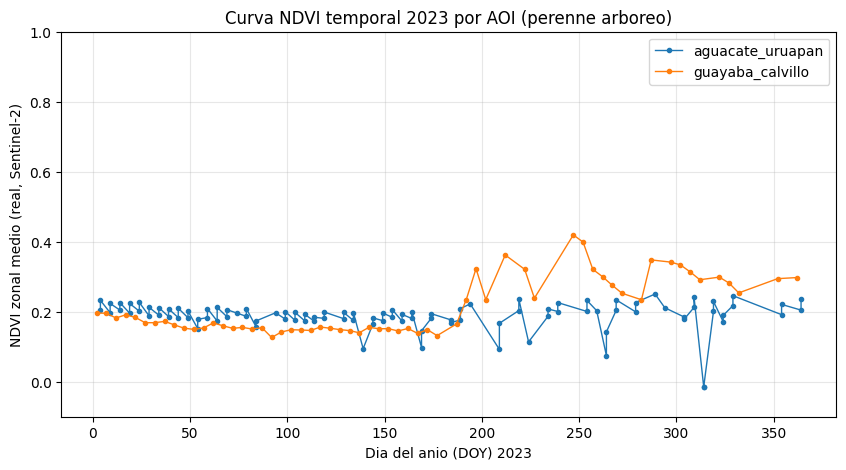

In [7]:
# Figura 2: NDVI vs DOY 2023, una linea por AOI (la fenologia real).
valid_ndvi = {k: v for k, v in ndvi_series.items() if not v.is_empty()}
if not degraded and valid_ndvi:
    fig, ax = plt.subplots(figsize=(10, 5))
    for name, ser in valid_ndvi.items():
        s = ser.sort('doy')
        ax.plot(
            s['doy'].to_numpy(), s['ndvi'].to_numpy(),
            marker='o', ms=3, lw=1, label=name,
        )
    ax.set_xlabel('Dia del anio (DOY) 2023')
    ax.set_ylabel('NDVI zonal medio (real, Sentinel-2)')
    ax.set_title('Curva NDVI temporal 2023 por AOI (perenne arboreo)')
    ax.set_ylim(-0.1, 1.0)
    ax.legend()
    ax.grid(True, alpha=0.3)
    display(fig)
    plt.close(fig)
else:
    display(Markdown(
        '> **Modo degradado / sin datos**: curva NDVI omitida (sin numeros).'
    ))


## 4. Descripcion fenologica REAL (alineacion fenologia-texto, Gemini)

Pasamos la curva NDVI REAL al generador de descripciones fenologicas (`ml/features/phenology_description.py`, prompt 3-bloques de Wen et al., Gemini 3.5 Flash, `temperature=0.0`). Es exactamente el modulo del proyecto europeo, reusado sin tocar. La descripcion captura cualitativamente la firma del perenne arboreo.

In [8]:
descriptions = {}
if not degraded and valid_ndvi:
    for name, ser in valid_ndvi.items():
        aoi = next(a for a in aois if a.name == name)
        text = mx.describe_phenology(ser, aoi, model=gemini_model)
        descriptions[name] = text
        display(Markdown(f'**{name}** ({aoi.crop}): {text}'))
else:
    display(Markdown(
        '> **Modo degradado / sin datos**: no se genera descripcion '
        '(requiere la curva NDVI real + `GEMINI_API_KEY`). Sin texto inventado.'
    ))


2026-06-20 07:12:56 [info     ] phenology_description_cache_hit parcel_id=aguacate_uruapan


**aguacate_uruapan** (aguacate): Esta parcela de aguacate en Michoacán presenta un comportamiento fenológico sumamente uniforme y plano a lo largo de todo el año, característico de un cultivo perenne arbóreo que mantiene su follaje constante. La curva muestra un nivel de pico de NDVI muy bajo que apenas sobresale de la línea base, lo que refleja una densidad foliar moderada o la presencia de suelo desnudo entre las copas de los árboles sin un desarrollo de cubierta herbácea vigorosa. No se observa una temporada de crecimiento rápido o estacional definida, sino más bien una estabilidad continua donde la madurez del dosel se prolonga de manera indefinida y larga durante todo el ciclo anual. El ligero incremento hacia el final del año representa una fluctuación menor dentro de un perfil vegetativo que carece de los ciclos marcados de siembra y cosecha propios de los cultivos anuales.

2026-06-20 07:12:56 [info     ] phenology_description_cache_hit parcel_id=guayaba_calvillo


**guayaba_calvillo** (guayaba): Esta parcela de guayaba en Calvillo muestra un comportamiento fenológico característico de un cultivo perenne con un manejo de ciclo inducido o producción concentrada en la segunda mitad del año, permaneciendo en un estado de latencia o suelo desnudo con valores mínimos de vegetación durante los primeros meses. El crecimiento foliar se inicia de forma sumamente rápida a mitad del verano, alcanzando un nivel de pico moderado a finales de la estación estival gracias al desarrollo de la copa del árbol y la brotación. Tras este máximo, se observa una senescencia o defoliación rápida que da paso a una ligera reactivación otoñal, lo que define una temporada agronómica de madurez corta y dinámica antes de estabilizarse al llegar el invierno.

## 5. Encuadre HCAT cualitativo (PERMANENT_WOODY / orchard, US-074)

El cultivo perenne arboreo (aguacate/guayaba) se **encuadra por analogia fenologica** en la familia `PERMANENT_WOODY` del label-space `hcat-macro` de US-074 (clases `orchard` / `vineyard`). Es la familia arborea/perenne mas cercana del espacio europeo.

> Esto es un **encuadre por analogia fenologica, NO una prediccion ni un F1**. No se llama a ningun clasificador ni se asigna probabilidad: solo se nombra la familia analoga del espacio de cultivos comun.

In [9]:
framing = mx.hcat_perennial_framing()
display(pl.DataFrame(
    {'clase_hcat_macro': list(framing.keys()), 'familia_macro': list(framing.values())}
))
display(Markdown(
    'La firma NDVI alta y estable de aguacate/guayaba es **analoga** a la de '
    'un huerto (`orchard`, familia `PERMANENT_WOODY`) del espacio HCAT comun. '
    'Es una analogia cualitativa, **no** una clasificacion.'
))


clase_hcat_macro,familia_macro
str,str
"""Grapevine""","""PERMANENT_WOODY|vineyard"""
"""Orchard""","""PERMANENT_WOODY|orchard"""


La firma NDVI alta y estable de aguacate/guayaba es **analoga** a la de un huerto (`orchard`, familia `PERMANENT_WOODY`) del espacio HCAT comun. Es una analogia cualitativa, **no** una clasificacion.

## 6. Export de los artefactos REALES (ligeros, al Git)

Serie NDVI por AOI + embedding AlphaEarth por AOI. Son KB, datos REALES de GEE; el cache crudo (`data/cache/gee/*.parquet`) NO se commitea (se regenera determinista).

In [10]:
ndvi_out = repo_root / 'data' / 'transfer' / 'mexico_demo_ndvi.parquet'
emb_out = repo_root / 'data' / 'transfer' / 'mexico_demo_alphaearth.parquet'
if not degraded and valid_ndvi and valid_emb:
    ndvi_out.parent.mkdir(parents=True, exist_ok=True)
    ndvi_frames = [
        ser.with_columns(pl.lit(name).alias('aoi')) for name, ser in valid_ndvi.items()
    ]
    ndvi_all = pl.concat(ndvi_frames).select('aoi', 'date', 'doy', 'ndvi')
    ndvi_all.write_parquet(ndvi_out)
    band_names = [f'A{i:02d}' for i in range(mx.ALPHAEARTH_N_DIMS)]
    emb_rows = []
    for name, vec in valid_emb.items():
        row = {'aoi': name, 'cultivo': next(a.crop for a in aois if a.name == name)}
        row.update({b: float(vec[i]) for i, b in enumerate(band_names)})
        emb_rows.append(row)
    emb_all = pl.DataFrame(emb_rows)
    emb_all.write_parquet(emb_out)
    rb_ndvi = pl.read_parquet(ndvi_out)
    rb_emb = pl.read_parquet(emb_out)
    assert rb_ndvi.height == ndvi_all.height, 'readback NDVI mismatch'
    assert rb_emb.height == emb_all.height, 'readback embedding mismatch'
    display(Markdown(
        f'NDVI -> `{ndvi_out}` ({rb_ndvi.height} filas reales); '
        f'embedding -> `{emb_out}` ({rb_emb.height} AOIs).'
    ))
else:
    display(Markdown(
        '> **Modo degradado / sin datos**: no se escribe parquet (sin datos reales).'
    ))


NDVI -> `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\transfer\mexico_demo_ndvi.parquet` (164 filas reales); embedding -> `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\transfer\mexico_demo_alphaearth.parquet` (2 AOIs).

## Conclusiones

**Que mostramos**: el **mismo** pipeline (AlphaEarth zonal + curva NDVI fenologica + descripcion-texto con Gemini) aplicado a dos huertas reales de Mexico -- aguacate en Uruapan/Tancitaro (Michoacan) y guayaba en Calvillo (Aguascalientes). La metodologia se **replica** a otra zona sin ningun cambio: AlphaEarth es global e incluye Mexico.

**Lo honesto del ejercicio**:
- Todo lo mostrado es REAL y sale de GEE: el embedding AlphaEarth de 64 dimensiones, la curva NDVI 2023 de Sentinel-2 (con el numero de imagenes reportado) y la descripcion fenologica generada por Gemini.
- **NO reportamos F1 ni accuracy para Mexico.** No existe un conjunto de ground-truth curado de aguacate/guayaba que permita validar una clasificacion. El encuadre HCAT (orchard) es una **analogia cualitativa** de la firma fenologica, no una prediccion.
- La curva alta y estable es coherente con un cultivo **perenne arboreo** (sin el pico estacional unico de un cereal anual).

**Lo que sigue**: una validacion metrica (un F1>=0.80 mexicano) requiere muestras etiquetadas curadas de aguacate/guayaba, que quedan como trabajo futuro. Hoy la evidencia es la **replicabilidad metodologica** zero-shot, con la honestidad de no afirmar una exactitud que no medimos.